# Step 12: Complementary Density Bands

**Hypothesis:** Alternation repeatedly controls different density bands; immediate A-to-B handoff is unnecessary.

Run the six standard schedules with normal spread and with spread disabled (12 simulations). Record actual removal by policy and density-band occupancy. All strategies start from the same population-derived state and share a budget ceiling. Run All; no other notebook is required.

In [1]:
from pathlib import Path
import os
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(p for p in (current, *current.parents) if (p / "src").is_dir())
os.chdir(repo_root)
from src.data_loader import load_locality_data
from src.weed_experiment import ExperimentConfig, run_experiment
from src.experiment_schedules import (
    PolicyParameters, ScheduledPolicy, BudgetLimitedPolicy,
    make_scheduled_policy, standard_schedules, budget_exhaustion_step,
)

SAMPLE_ID = 2036
STEPS = 100  # Change to 260 to inspect a longer horizon.
row = pd.read_csv(repo_root / "results/strong_parrondo_finalists.csv").set_index("sample_id").loc[SAMPLE_ID]
budget = float(row.budget) * STEPS / 100
parameters = PolicyParameters(
    a_rate=float(row.a_rate), b_rate=float(row.b_rate),
    max_cells=int(row.max_cells), boundary=float(row.boundary),
    b_lower=float(row.b_lower), unit_cost=200.0,
)
config = ExperimentConfig(steps=STEPS, growth_rate=float(row.growth_rate), diffusion_rate=float(row.diffusion_rate))
localities = load_locality_data(repo_root / "data")
metro = localities[localities.postcode.astype(int).between(6000, 6199)].copy()
schedules = standard_schedules(STEPS)
print(f"Candidate {SAMPLE_ID}; steps={STEPS}; budget ceiling={budget:,.0f}")


Candidate 2036; steps=100; budget ceiling=250,000


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,sample_id,steps,setting,strategy,relative_change,final_cost,budget_exhaustion_step,A_removed,B_removed
0,2036,100,normal spread,A only,0.041958,149107.484375,None,745.537427,0.000000
1,2036,100,normal spread,B only,0.014206,199967.171875,None,0.000000,999.835824
2,2036,100,normal spread,AB,-0.002064,228212.656250,None,374.479945,766.583352
3,2036,100,normal spread,BA,-0.003486,229166.359375,None,374.485973,771.345846
4,2036,100,normal spread,A block B,0.047051,138087.875000,None,374.279280,316.160136
5,2036,100,normal spread,B block A,0.029926,173466.421875,None,374.597255,492.734818
6,2036,100,no spread,A only,-0.014212,148885.515625,None,744.427614,0.000000
7,2036,100,no spread,B only,-0.000684,79969.007812,None,0.000000,399.845039
8,2036,100,no spread,AB,-0.029983,139577.515625,None,374.469040,323.418552
9,2036,100,no spread,BA,-0.031173,140746.234375,None,374.474340,329.256806


strategy,A block B,A only,AB,B block A,B only,BA,strong_reversal
setting,,,,,,,
no spread,-0.004864,-0.014212,-0.029983,-0.028277,-0.000684,-0.031173,False
normal spread,0.047051,0.041958,-0.002064,0.029926,0.014206,-0.003486,True


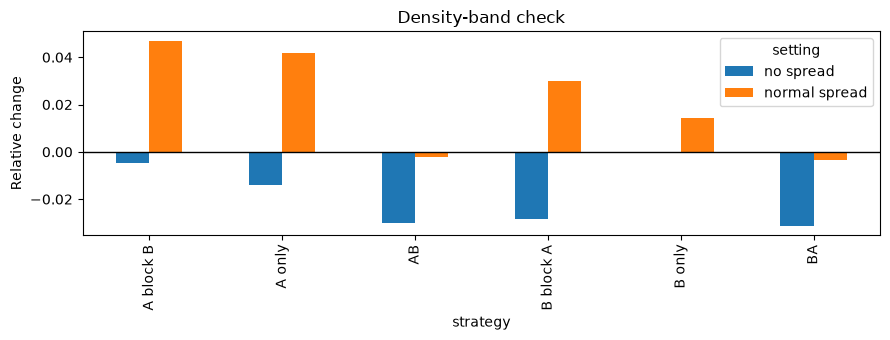

In [2]:
class BandRecorder:
    def __init__(self, schedule):
        self.schedule = schedule
        self.inner = make_scheduled_policy(schedule, parameters, budget)
        self.reset()

    def reset(self):
        self.inner.reset()
        self.index = 0
        self.events = []

    def __call__(self, grid, mask):
        removal, cost = self.inner(grid, mask)
        medium = mask & (grid >= parameters.b_lower) & (grid < parameters.boundary)
        high = mask & (grid >= parameters.boundary)
        self.events.append({
            "step": self.index + 1, "policy": self.schedule[self.index],
            "medium_cells_before_removal": int(medium.sum()),
            "high_cells_before_removal": int(high.sum()),
            "medium_removed": float(removal[medium].sum()),
            "high_removed": float(removal[high].sum()), "cost": float(cost),
        })
        self.index += 1
        return removal, cost

rows, event_tables = [], []
for setting, diffusion in (("normal spread", config.diffusion_rate), ("no spread", 0.0)):
    for strategy, schedule in schedules.items():
        observer = BandRecorder(schedule)
        result = run_experiment(strategy, metro, replace(config, diffusion_rate=diffusion), observer)
        trace = pd.DataFrame(observer.events).assign(setting=setting, strategy=strategy, sample_id=SAMPLE_ID)
        event_tables.append(trace)
        rows.append({"sample_id": SAMPLE_ID, "steps": STEPS, "setting": setting, "strategy": strategy,
                     "relative_change": result.relative_change, "final_cost": result.final_cost,
                     "budget_exhaustion_step": budget_exhaustion_step(result.cost_history, budget),
                     "A_removed": float(trace.loc[trace.policy == "A", ["medium_removed", "high_removed"]].to_numpy().sum()),
                     "B_removed": float(trace.loc[trace.policy == "B", ["medium_removed", "high_removed"]].to_numpy().sum())})
summary = pd.DataFrame(rows)
display(summary.round(6))
wide = summary.pivot(index="setting", columns="strategy", values="relative_change")
wide["strong_reversal"] = (wide[["A only", "B only", "A block B", "B block A"]] > 0).all(axis=1) & (wide[["AB", "BA"]] < 0).all(axis=1)
display(wide)
summary.to_csv(repo_root / "results/step12_density_band_summary.csv", index=False)
pd.concat(event_tables, ignore_index=True).to_csv(repo_root / "results/step12_density_band_events.csv", index=False)
wide.drop(columns="strong_reversal").T.plot.bar(figsize=(9, 3.5), ylabel="Relative change", title="Density-band check")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()


## Observed results: candidate 2036, 100 steps

With normal spread, A only and B only increased the mean index by **4.196%** and **1.421%**, while AB and BA reduced it by **0.206%** and **0.349%**. Both block schedules lost, so the strict reversal was reproduced.

With spread disabled, **all six schedules improved**. A only improved by 1.421%, B only by 0.068%, AB by 2.998%, and BA by 3.117%. Alternation remained the best of the tested schedules, but the strict reversal disappeared because the individual policies also won. This is not a failure of alternating control.

**Interpretation:** Ecological spread is required for the observed losing-alone/winning-together pattern in this specific comparison. However, an alternating advantage also exists without spread, so spread is not its sole possible source. Complementary density-band treatment remains plausible, but this experiment does not establish it as the cause.

A's total removal was almost unchanged between spread settings for each schedule. In AB, B's removal rose from about **323.42** index units without spread to **766.58** with spread; BA showed a similar increase. This is consistent with ecological spread sustaining more treatment demand for B, but it does not isolate how cells enter the eligible set.

No run exhausted its 250,000 ceiling. Actual expenditure differed across strategies and spread settings. B retained its spatial-score targeting even with ecological spread disabled. Event counts describe occupancy before removal, not isolated regrowth. These findings apply to candidate 2036 at 100 steps only.